In [1]:
#Task1
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

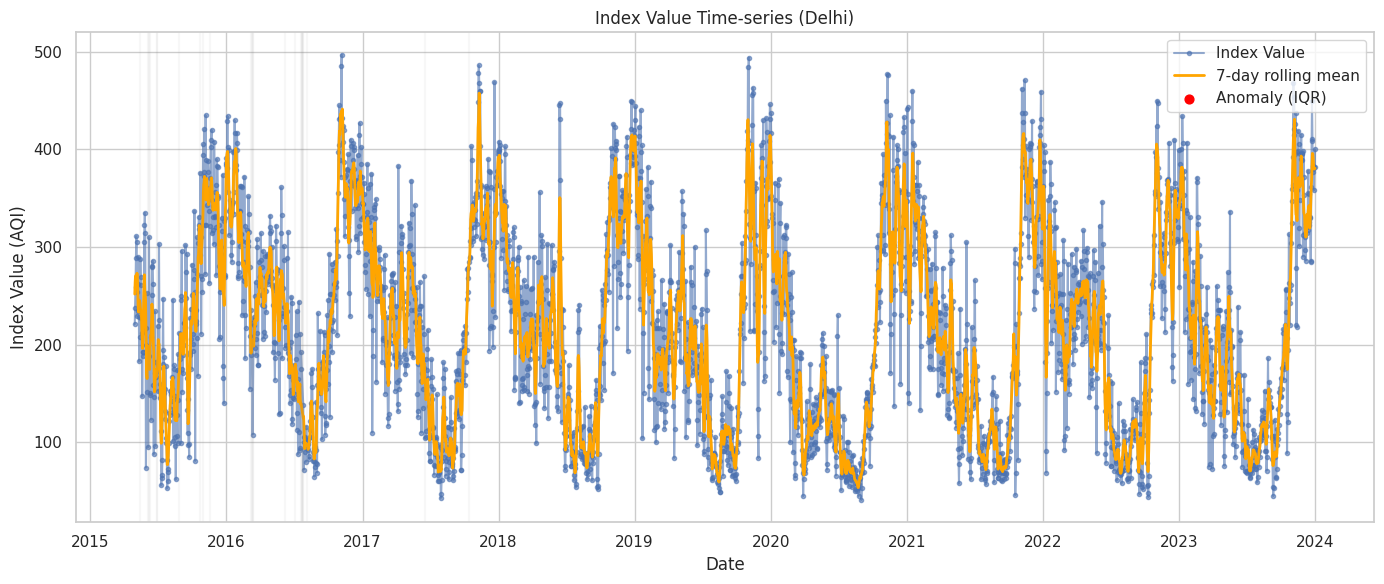

Missing dates count: 24
Anomalies detected (IQR): 0


/tmp/ipython-input-4074383897.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


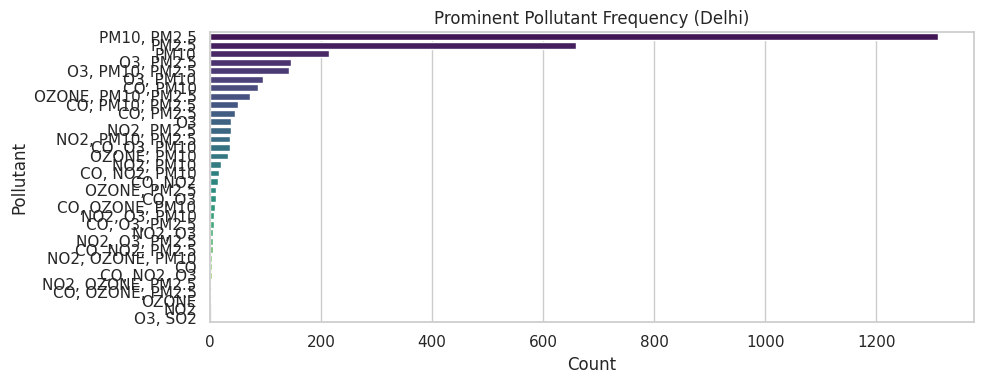

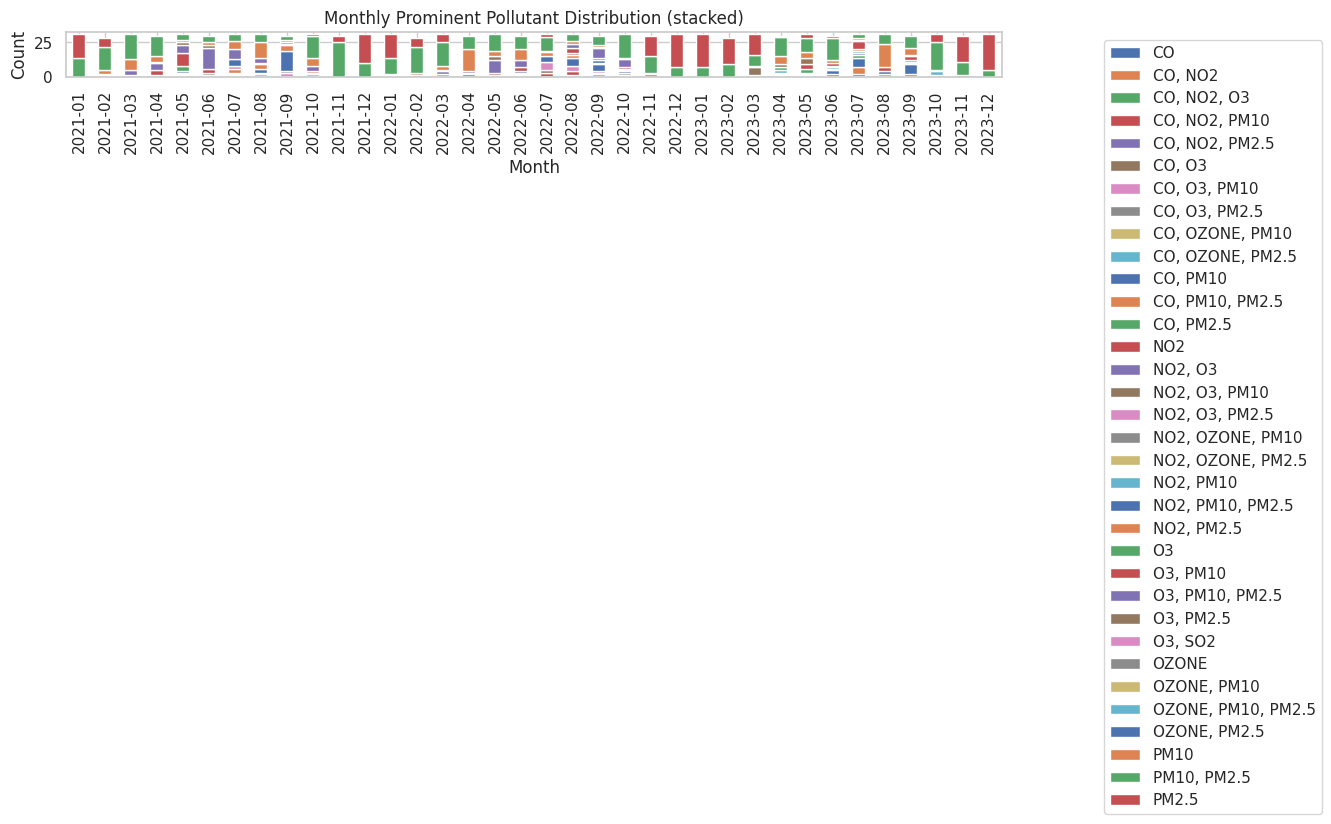

In [5]:
sns.set(style="whitegrid")
df = pd.read_csv("Delhi_AQIBulletins.csv", low_memory=False)
df.columns = [c.strip() for c in df.columns]

def find_col_like(df, keywords):
    for k in keywords:
        for c in df.columns:
            if k.lower() in c.lower().replace('_',' ').replace('.',' '):
                return c
    return None

date_col = find_col_like(df, ['date','day'])
index_col = find_col_like(df, ['index value','index','value','aqi'])
pollutant_col = find_col_like(df, ['prominent pollutant','prominent','pollutant'])
city_col = find_col_like(df, ['city','location'])

if not date_col or not index_col:
    raise RuntimeError("Required columns not found")

rename_map = {date_col:'Date', index_col:'Index Value'}
if pollutant_col: rename_map[pollutant_col] = 'Prominent Pollutant'
if city_col: rename_map[city_col] = 'City'
df = df.rename(columns=rename_map)

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df[df['Date'].notna()].copy()
df = df.sort_values('Date').reset_index(drop=True)
df['Index Value'] = pd.to_numeric(df['Index Value'], errors='coerce')

if 'City' in df.columns and df['City'].notna().any():
    selected_city = df['City'].dropna().unique()[0]
    city_df = df[df['City'].astype(str).str.strip().str.lower()==selected_city.strip().lower()].copy()
    if city_df.empty:
        city_df = df.copy()
else:
    city_df = df.copy()

city_df = city_df.set_index('Date').sort_index()
rolling_window = 7
city_df['Roll'] = city_df['Index Value'].rolling(window=rolling_window, min_periods=1, center=True).mean()
min_date, max_date = city_df.index.min(), city_df.index.max()
full_index = pd.date_range(min_date, max_date, freq='D')
missing_dates = full_index.difference(city_df.index)
series = city_df['Index Value'].dropna()
q1, q3 = series.quantile(0.25), series.quantile(0.75)
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5*iqr, q3 + 1.5*iqr
city_df['Anomaly'] = ((city_df['Index Value'] < lower_bound) | (city_df['Index Value'] > upper_bound))

plt.figure(figsize=(14,6))
plt.plot(city_df.index, city_df['Index Value'], label='Index Value', marker='o', markersize=3, linestyle='-', alpha=0.6)
plt.plot(city_df.index, city_df['Roll'], label=f'{rolling_window}-day rolling mean', linewidth=2, color='orange')
for d in missing_dates:
    plt.axvline(d, color='gray', alpha=0.06)
anoms = city_df[city_df['Anomaly']==True]
plt.scatter(anoms.index, anoms['Index Value'], color='red', label='Anomaly (IQR)', s=40, zorder=5)
plt.title(f"Index Value Time-series ({selected_city if 'City' in df.columns else 'All Data'})")
plt.xlabel("Date")
plt.ylabel("Index Value (AQI)")
plt.legend()
plt.tight_layout()
plt.show()

print("Missing dates count:", len(missing_dates))
print("Anomalies detected (IQR):", int(city_df['Anomaly'].sum()))

if 'Prominent Pollutant' in city_df.columns:
    city_df['Prominent Pollutant'] = city_df['Prominent Pollutant'].fillna("Unknown").astype(str)
    counts = city_df['Prominent Pollutant'].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(10,4))
    sns.barplot(x=counts.values, y=counts.index, palette="viridis")
    plt.title(f"Prominent Pollutant Frequency ({selected_city if 'City' in df.columns else 'All Data'})")
    plt.xlabel("Count")
    plt.ylabel("Pollutant")
    plt.tight_layout()
    plt.show()

    df_reset = city_df.reset_index()
    df_reset['Month'] = df_reset['Date'].dt.to_period('M').astype(str)
    monthly = df_reset.groupby(['Month','Prominent Pollutant']).size().unstack(fill_value=0)
    if monthly.shape[0] >= 3:
        monthly.tail(36).plot(kind='bar', stacked=True, figsize=(14,5))
        plt.title("Monthly Prominent Pollutant Distribution (stacked)")
        plt.xlabel("Month")
        plt.ylabel("Count")
        plt.legend(loc='upper right', bbox_to_anchor=(1.35,1))
        plt.tight_layout()
        plt.show()
else:
    print("Prominent Pollutant column not found")

In [6]:
#Task 2
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [8]:
data = city_df.copy()

data = data[['Index Value']].dropna()
values = data.values.astype('float32')

scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

def create_windowed(data, window=7):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 7
X, y = create_windowed(scaled, window)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = np.array(X_train)
X_test = np.array(X_test)

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(window,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=0)

y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

rmse = sqrt(mean_squared_error(y_test_actual, y_pred))
print("RMSE:", rmse)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
RMSE: 41.58537904119668


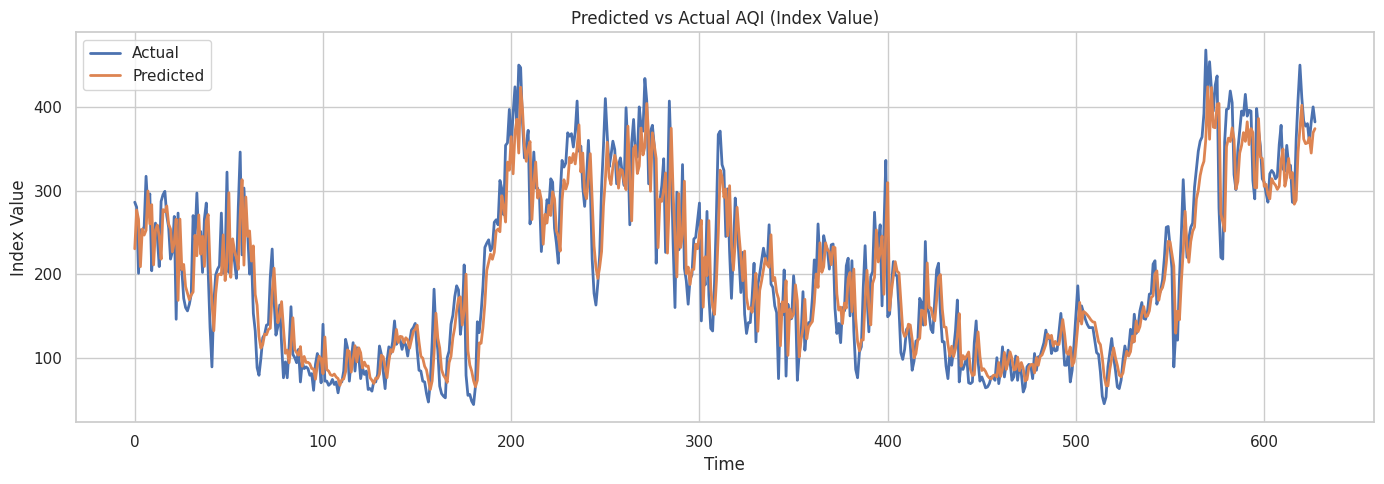

In [9]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted', linewidth=2)
plt.title("Predicted vs Actual AQI (Index Value)")
plt.xlabel("Time")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
plt.show()

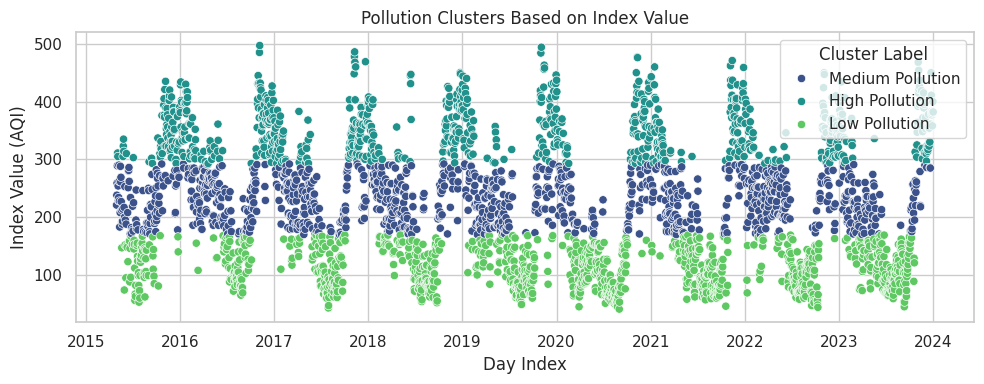

/tmp/ipython-input-244845512.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Cluster Label', palette="viridis")


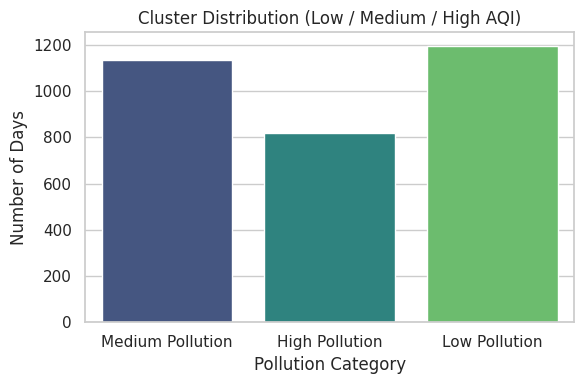

Cluster Centers (sorted):
Low Pollution → center Index Value = 110.08
Medium Pollution → center Index Value = 229.72
High Pollution → center Index Value = 356.16

Interpretation:
Low Pollution: Days with lowest AQI values (clean air conditions).
Medium Pollution: Normal/moderate AQI range (average days).
High Pollution: Peaks/extreme values (polluted or hazardous days).


In [12]:
#Task 3
from sklearn.cluster import KMeans

values = data[['Index Value']].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(values)

data = values.copy()
data['Cluster'] = clusters

centers = kmeans.cluster_centers_.flatten()
order = np.argsort(centers)

cluster_labels = {}
cluster_labels[order[0]] = 'Low Pollution'
cluster_labels[order[1]] = 'Medium Pollution'
cluster_labels[order[2]] = 'High Pollution'

data['Cluster Label'] = data['Cluster'].map(cluster_labels)

plt.figure(figsize=(10,4))
sns.scatterplot(x=data.index, y=data['Index Value'], hue=data['Cluster Label'], palette="viridis")
plt.title("Pollution Clusters Based on Index Value")
plt.xlabel("Day Index")
plt.ylabel("Index Value (AQI)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Cluster Label', palette="viridis")
plt.title("Cluster Distribution (Low / Medium / High AQI)")
plt.xlabel("Pollution Category")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

print("Cluster Centers (sorted):")
for idx in order:
    print(cluster_labels[idx], "→ center Index Value =", round(centers[idx], 2))

print("\nInterpretation:")
print("Low Pollution: Days with lowest AQI values (clean air conditions).")
print("Medium Pollution: Normal/moderate AQI range (average days).")
print("High Pollution: Peaks/extreme values (polluted or hazardous days).")

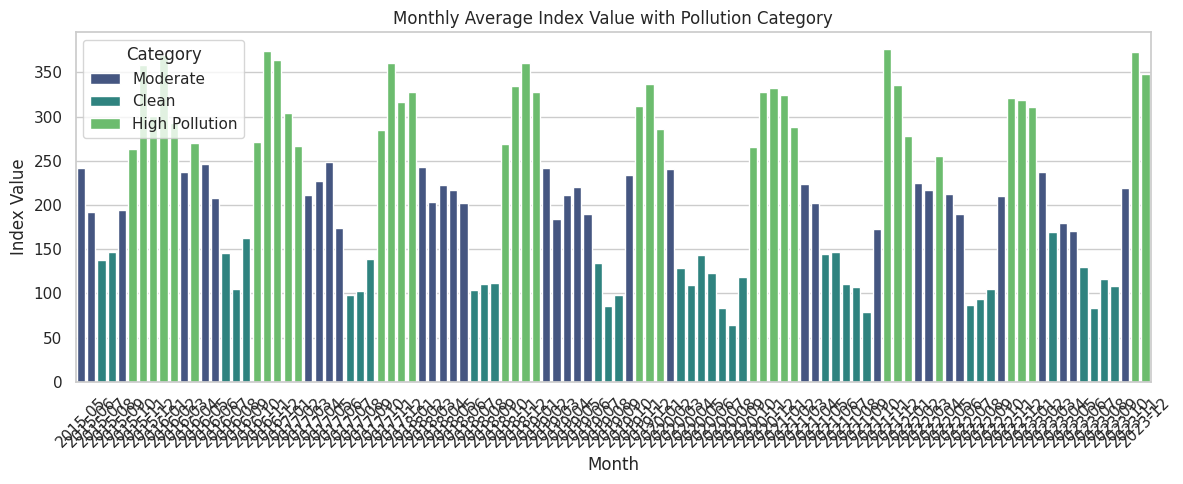

Monthly Average Index Values:


,Month,Index Value,Category
0,2015-05,242.333333,Moderate
1,2015-06,191.920000,Moderate
2,2015-07,138.129032,Clean
3,2015-08,147.100000,Clean
4,2015-09,194.466667,Moderate
...,...,...,...
99,2023-08,116.483871,Clean
100,2023-09,107.833333,Clean
101,2023-10,218.935484,Moderate
102,2023-11,372.866667,High Pollution



Seasonal Insights:
High pollution months: 2015-10, 2015-11, 2015-12, 2016-01, 2016-02, 2016-04, 2016-10, 2016-11, 2016-12, 2017-01, 2017-02, 2017-10, 2017-11, 2017-12, 2018-01, 2018-10, 2018-11, 2018-12, 2019-01, 2019-11, 2019-12, 2020-01, 2020-10, 2020-11, 2020-12, 2021-01, 2021-02, 2021-11, 2021-12, 2022-01, 2022-04, 2022-11, 2022-12, 2023-01, 2023-11, 2023-12
Moderate pollution months: 2015-05, 2015-06, 2015-09, 2016-03, 2016-05, 2016-06, 2017-03, 2017-04, 2017-05, 2017-06, 2018-02, 2018-03, 2018-04, 2018-05, 2018-06, 2019-02, 2019-03, 2019-04, 2019-05, 2019-06, 2019-10, 2020-02, 2021-03, 2021-04, 2021-10, 2022-02, 2022-03, 2022-05, 2022-06, 2022-10, 2023-02, 2023-04, 2023-05, 2023-10
Clean air months: 2015-07, 2015-08, 2016-07, 2016-08, 2016-09, 2017-07, 2017-08, 2017-09, 2018-07, 2018-08, 2018-09, 2019-07, 2019-08, 2019-09, 2020-03, 2020-04, 2020-05, 2020-06, 2020-07, 2020-08, 2020-09, 2021-05, 2021-06, 2021-07, 2021-08, 2021-09, 2022-07, 2022-08, 2022-09, 2023-03, 2023-06, 2023-

In [13]:
#Task 4
df4 = city_df.copy().reset_index()
df4['Month'] = df4['Date'].dt.to_period('M').astype(str)
monthly_avg = df4.groupby('Month')['Index Value'].mean().reset_index()
values = monthly_avg['Index Value']

low_th = values.quantile(0.33)
high_th = values.quantile(0.66)

def categorize(v):
    if v <= low_th:
        return "Clean"
    elif v <= high_th:
        return "Moderate"
    else:
        return "High Pollution"

monthly_avg['Category'] = monthly_avg['Index Value'].apply(categorize)

plt.figure(figsize=(12,5))
sns.barplot(data=monthly_avg, x='Month', y='Index Value', hue='Category', palette="viridis")
plt.xticks(rotation=45)
plt.title("Monthly Average Index Value with Pollution Category")
plt.tight_layout()
plt.show()

high_months = monthly_avg[monthly_avg['Category']=="High Pollution"]['Month'].tolist()
moderate_months = monthly_avg[monthly_avg['Category']=="Moderate"]['Month'].tolist()
clean_months = monthly_avg[monthly_avg['Category']=="Clean"]['Month'].tolist()

print("Monthly Average Index Values:")
display(monthly_avg)

print("\nSeasonal Insights:")
if high_months:
    print("High pollution months:", ", ".join(high_months))
else:
    print("No high-pollution months identified.")

if moderate_months:
    print("Moderate pollution months:", ", ".join(moderate_months))
if clean_months:
    print("Clean air months:", ", ".join(clean_months))

if high_months:
    print("\nInsight: The months listed under high pollution show consistently elevated AQI, indicating seasonal factors such as winter fog, festival emissions, or crop burning.")
else:
    print("\nInsight: Pollution levels remain mostly within Clean/Moderate ranges across months, showing no severe seasonal spikes.")